In [1]:
# Imports.
import numpy as np;
import xarray as xr;
import matplotlib.pyplot as plt;
import h5_reader_xr as reader;
import gysela_utilities as gys_utils;
import phi2D_utilities as utils;
import phi2D_analytical as analytical;

# Styling.
plt.style.use("ggplot");

In [2]:
# Test inputs - delete when done!
directory_path = "/zhisongqu_data/seth/GYSELA/raw/fresh_batch_10.0/DN_RHTEST_A3_GG2019";
data_arrays = reader.fetch_phi2D_data(directory_path, parallelise = True);

Found 2001 files in the directory. Loading with 16 workers...


[Parallel(n_jobs=16)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    2.0s
[Parallel(n_jobs=16)]: Done 464 tasks      | elapsed:    2.8s


Finished compiling data from all files in the directory.


[Parallel(n_jobs=16)]: Done 2001 out of 2001 | elapsed:    5.3s finished


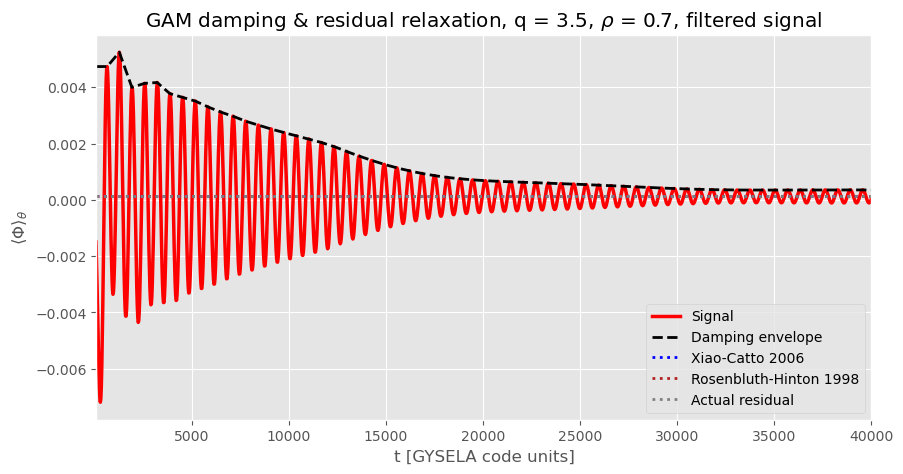

In [9]:
def plot_rosenbluth_hinton(phi2D_list, dt_diag, aspect_ratio, safety_factor, title_suffix = "", effective_radius = 0.7, residual_window = 100, signal_band_pass = True):
	
	# Signal isolation and data processing.
	radial_time_series = utils.generate_poloidally_averaged_time_series(phi2D_list, effective_radius);

	if signal_band_pass:
		radial_time_series = utils.butterworth_band_pass_filter(radial_time_series, dt_diag);

	# We recover the actual time in code units here (normalised to the ion cyclotron frequency).
	# This does not actually change the size of the array, only its spacing.
	time_range = gys_utils.generate_time_range_by_series(radial_time_series, dt_diag);
	GAM_frequency = utils.extract_gam_frequency(phi2D_list, dt_diag, effective_radius);
	amplitude_envelope = utils.generate_damping_envelope(radial_time_series, GAM_frequency, dt_diag);
	initial_amplitude = max(amplitude_envelope);
	residual_level = utils.calculate_residual_level(amplitude_envelope, residual_window, use_heuristic_approach = True);
	residual_level_xc2006 = analytical.residual_XiaoCatto2006(1. / aspect_ratio, safety_factor, k_rho = 0.01) * initial_amplitude;
	residual_level_rh1998 = analytical.residual_RosenbluthHinton1998(1. / aspect_ratio, safety_factor) * initial_amplitude;

	if signal_band_pass:
		# Restore residual levels as the band-pass eliminates this information.
		radial_time_series += residual_level;
		amplitude_envelope += residual_level;

	# Figure plotting logic.
	plt.figure(figsize = (10, 5));
	plt.plot(time_range, radial_time_series, color = "red", lw = 2.5, label = "Signal");
	plt.plot(time_range, amplitude_envelope, color = "black", linestyle = "--", label= "Damping envelope", lw = 2.0);
	plt.axhline(y = residual_level_xc2006, color = "blue", linestyle = ":", label = "Xiao-Catto 2006", lw = 2.0);
	plt.axhline(y = residual_level_rh1998, color = "firebrick", linestyle = ":", label = "Rosenbluth-Hinton 1998", lw = 2.0);
	plt.axhline(y = residual_level, color = "gray", linestyle = ":", label = "Actual residual", lw = 2.0);
	plt.xlabel("t [GYSELA code units]");
	plt.ylabel(r"$\langle \Phi \rangle_\theta$");
	plt.xlim(left = 100, right = 40000)
	plt.title(f"GAM damping & residual relaxation, q = 3.5, $\\rho$ = {effective_radius}, {title_suffix}");
	plt.legend(frameon = True, loc = "lower right");
	plt.show();

plot_rosenbluth_hinton(data_arrays, dt_diag = 25, aspect_ratio = 3.0, safety_factor = 3.5, effective_radius = 0.7, residual_window = 100, title_suffix = "filtered signal", signal_band_pass = True);